In [3]:
# ==========================
# STEP 1: SETUP
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [4]:
from google.colab import files
uploaded = files.upload()  # upload your zip file


Saving archive (17).zip to archive (17).zip


In [6]:
zip_path = "/content/archive (17).zip"   # change to your uploaded file name
extract_path = "/content/Thyroid_Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = extract_path

In [7]:
# ==========================
# STEP 3: DATA GENERATORS
# ==========================
img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 2492 images belonging to 1 classes.
Found 623 images belonging to 1 classes.


In [8]:
# ==========================
# STEP 4: SIMPLE CNN MODEL
# ==========================
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn_model.fit(train_gen, validation_data=val_gen, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [9]:
# ==========================
# STEP 5: VGG16 TRANSFER LEARNING
# ==========================
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
for layer in base_vgg.layers:
    layer.trainable = False

x = Flatten()(base_vgg.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_vgg.input, outputs=predictions)
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg = vgg_model.fit(train_gen, validation_data=val_gen, epochs=5)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 24s 218ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [10]:
# ==========================
# STEP 6: RANDOM FOREST ON FEATURES
# ==========================
feature_extractor = Model(inputs=base_vgg.input, outputs=Flatten()(base_vgg.output))

train_features = feature_extractor.predict(train_gen)
train_labels = train_gen.classes

val_features = feature_extractor.predict(val_gen)
val_labels = val_gen.classes

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_features, train_labels)

rf_preds = rf.predict(val_features)
rf_acc = accuracy_score(val_labels, rf_preds)
print("Random Forest Validation Accuracy:", rf_acc)


78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
Random Forest Validation Accuracy: 1.0


In [16]:
print(train_gen.class_indices)


{'Thyroid Data': 0}


Class mapping will be: ['1', '0']
Found 2492 images belonging to 2 classes.
Found 623 images belonging to 2 classes.
Class indices: {'0': 0, '1': 1}
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.5990 - loss: 4.7611 - val_accuracy: 0.6116 - val_loss: 1.9319
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.7025 - loss: 1.3873 - val_accuracy: 0.6404 - val_loss: 1.2700
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.7977 - loss: 0.6465 - val_accuracy: 0.5827 - val_loss: 1.1926
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.8245 - loss: 0.4241 - val_accuracy: 0.5891 - val_loss: 1.1207
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.8726 - loss: 0.3091 - val_accuracy: 0.6051 - val_loss: 1.0734
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9023 - loss: 0.2467 - val_accuracy: 0.5971 - val_loss: 1.1079
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.9254 - loss: 0.1779 - val_accuracy: 0.5987 - val_loss: 1.1796
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9481 - loss: 0.1417 - val_accuracy: 0.5859 - val_loss:

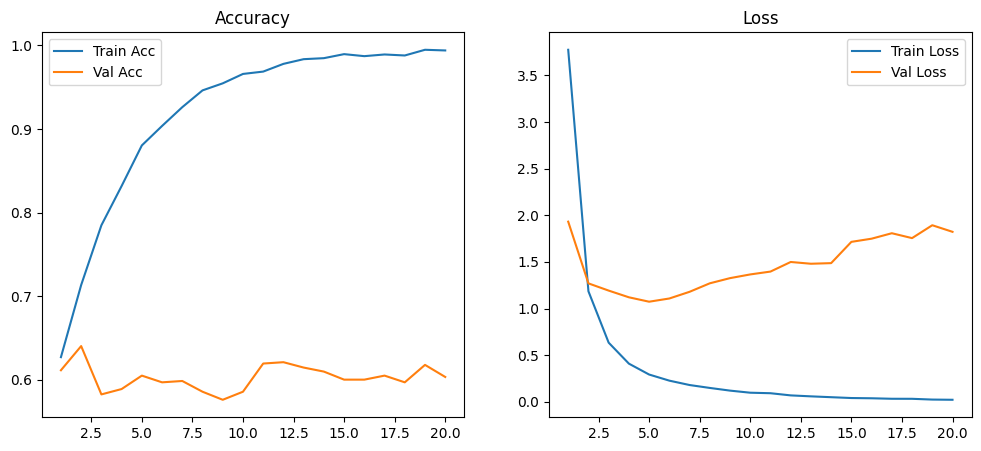

In [18]:
#CODE FROM HERE


# ==========================
# STEP 1: SETUP
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from google.colab import files

# ==========================
# STEP 2: UNZIP DATASET
# ==========================
zip_path = "/content/archive (17).zip"
extract_path = "/content/Thyroid Data"


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = os.path.join(extract_path, "Thyroid Data")

# Check label mapping
print("Class mapping will be:", os.listdir(base_dir))

# ==========================
# STEP 3: DATA GENERATORS
# ==========================
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_gen.class_indices)  # {'0':0, '1':1}

# ==========================
# STEP 4: BUILD VGG16 MODEL
# ==========================
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze all layers first
for layer in base_vgg.layers:
    layer.trainable = False

x = Flatten()(base_vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

vgg_model = Model(inputs=base_vgg.input, outputs=output)
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================
# STEP 5: TRAIN (frozen layers)
# ==========================
history = vgg_model.fit(train_gen, validation_data=val_gen, epochs=10)

# ==========================
# STEP 6: FINE-TUNE (unfreeze last 4 conv layers)
# ==========================
for layer in base_vgg.layers[-4:]:
    layer.trainable = True

vgg_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_ft = vgg_model.fit(train_gen, validation_data=val_gen, epochs=10)

# ==========================
# STEP 7: PLOT TRAINING CURVES
# ==========================
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc)+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.show()

plot_history(history, history_ft)

# ==========================
# STEP 8: PREDICT ON NEW IMAGE
# ==========================
def predict_new_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = vgg_model.predict(img_array)
    class_idx = np.argmax(preds, axis=1)[0]

    mapping = {v:k for k,v in train_gen.class_indices.items()}
    predicted_class = mapping[class_idx]

    return "Thyroid Detected" if predicted_class == "1" else "No Thyroid"

In [21]:
# Example: Upload new test image
uploaded = files.upload()
for fn in uploaded.keys():
    result = predict_new_image(fn)
    print(f"Prediction for {fn}: {result}")

Saving throid detected.png to throid detected.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction for throid detected.png: No Thyroid


In [22]:
print(os.listdir(base_dir))


['1', '0']


In [23]:
print(train_gen.class_indices)


{'0': 0, '1': 1}


In [28]:
# ==========================
# STEP 8: PREDICT ON NEW IMAGE (CORRECTED)
# ==========================
def predict_new_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = vgg_model.predict(img_array)
    class_idx = np.argmax(preds, axis=1)[0]
    confidence = np.max(preds)

    # Map numeric index back to class name
    mapping = {v:k for k,v in train_gen.class_indices.items()}
    predicted_class = mapping[class_idx]

    print(f"Predicted probabilities: {preds}")
    print(f"Predicted class name: {predicted_class}")

    if predicted_class.lower() == "thyroid":
        return f"Thyroid Detected (Confidence: {confidence:.2f})"
    else:
        return f"No Thyroid (Confidence: {confidence:.2f})"


# Upload new test image(s)
uploaded = files.upload()
for fn in uploaded.keys():
    result = predict_new_image(fn)
    print(f"Prediction for {fn}: {result}")


Saving Normal-thyroid-gland.png to Normal-thyroid-gland (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted probabilities: [[9.9999702e-01 2.9246623e-06]]
Predicted class name: 0
Prediction for Normal-thyroid-gland (1).png: No Thyroid (Confidence: 1.00)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 286ms/step


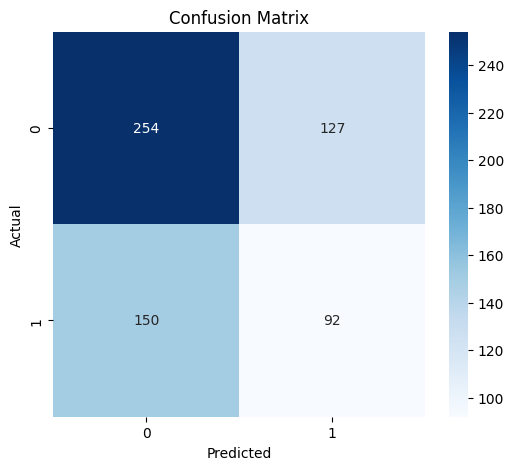


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       381
           1       0.42      0.38      0.40       242

    accuracy                           0.56       623
   macro avg       0.52      0.52      0.52       623
weighted avg       0.55      0.56      0.55       623



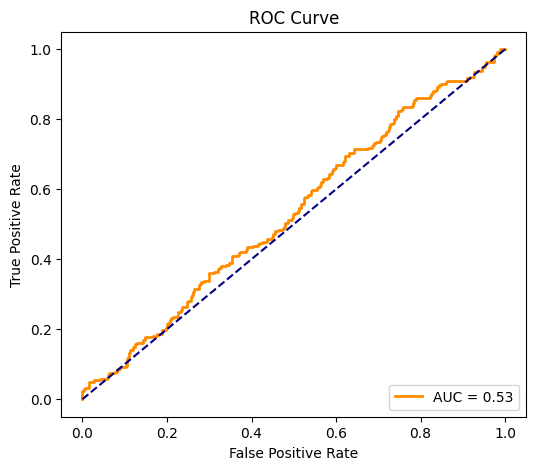

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


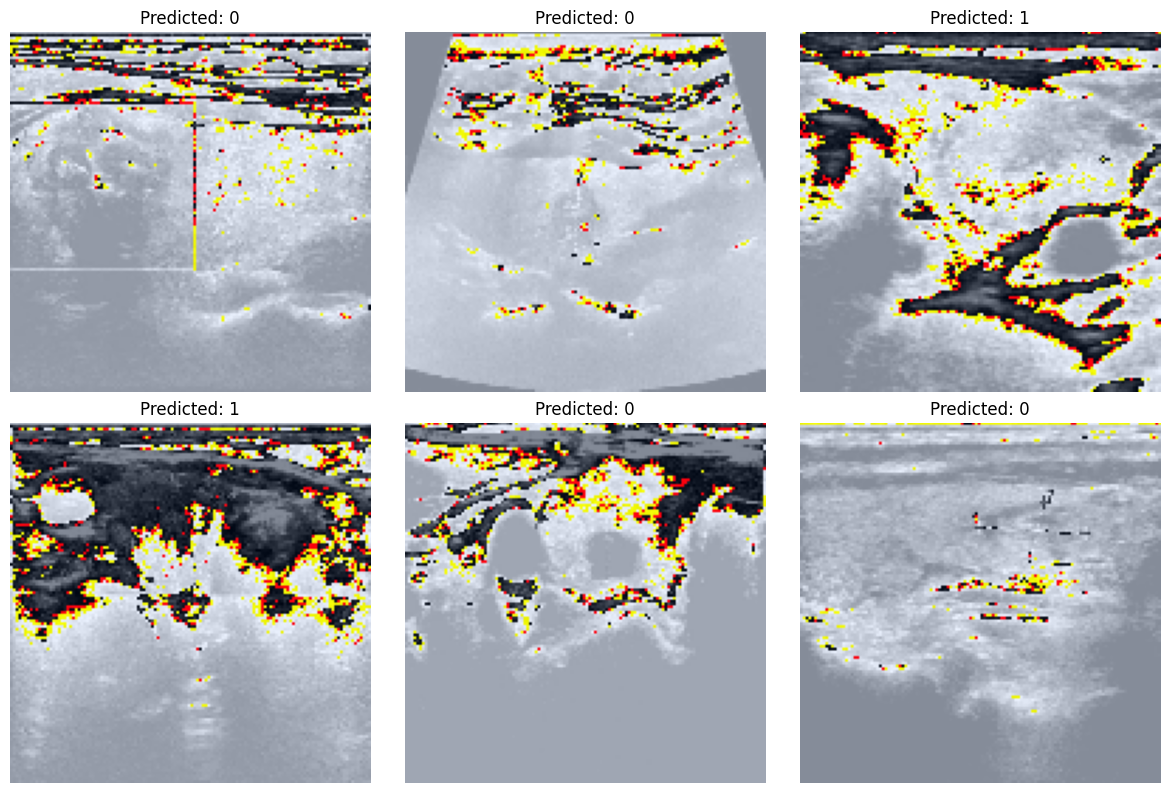

In [30]:
# ==========================
# STEP 9: MODEL EVALUATION & VISUALIZATION
# ==========================
val_gen.reset()
y_true = val_gen.classes
y_pred = vgg_model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(val_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# ROC Curve (binary only)
if len(class_names) == 2:
    fpr, tpr, _ = roc_curve(y_true, y_pred[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', color='navy')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

# Random Sample Predictions
plt.figure(figsize=(12,8))
for i in range(6):
    idx = random.randint(0, len(val_gen.filenames)-1)
    img_path = os.path.join(base_dir, val_gen.filenames[idx])
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = preprocess_input(img_array_exp)
    pred = vgg_model.predict(img_array_exp)
    pred_class = np.argmax(pred)
    label = class_names[pred_class]

    plt.subplot(2,3,i+1)
    plt.imshow(img_array.astype('uint8'))
    plt.title(f"Predicted: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#CUSTOMIZED CNN MODEL:

In [31]:


# ==========================
# STEP 1: SETUP
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [32]:
from google.colab import files
uploaded = files.upload()  # upload your dataset zip file


Saving archive (17).zip to archive (17) (1).zip


In [34]:
zip_path = "/content/archive (17).zip"   # change name if different
extract_path = "/content/Thyroid_Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = extract_path
print("Dataset extracted to:", base_dir)

Dataset extracted to: /content/Thyroid_Data


In [35]:
# ==========================
# STEP 3: DATA GENERATORS
# ==========================
img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 2492 images belonging to 1 classes.
Found 623 images belonging to 1 classes.


In [36]:
import os

for root, dirs, files in os.walk("/content/Thyroid_Data"):
    print("Current path:", root)
    print("Subfolders:", dirs)
    print("Example files:", files[:3])
    print("--------")
    break


Current path: /content/Thyroid_Data
Subfolders: ['Thyroid Data']
Example files: []
--------


In [37]:
base_dir = "/content/Thyroid_Data/Thyroid Data"


In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 2492 images belonging to 2 classes.
Found 623 images belonging to 2 classes.


In [39]:
# ==========================
# STEP 4: CUSTOMIZED CNN MODEL
# ==========================
custom_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

custom_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,834 (16.36 MB)

 Trainable params: 4,288,386 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [40]:
# ==========================
# STEP 5: COMPILE & TRAIN
# ==========================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/best_custom_model.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

# Compile
custom_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_custom = custom_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6000 - loss: 1.3753
Epoch 1: val_accuracy improved from -inf to 0.38844, saving model to /content/best_custom_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - accuracy: 0.6001 - loss: 1.3709 - val_accuracy: 0.3884 - val_loss: 2.3150
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6657 - loss: 0.6141
Epoch 2: val_accuracy did not improve from 0.38844
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.6658 - loss: 0.6141 - val_accuracy: 0.3884 - val_loss: 2.5657
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6942 - loss: 0.5582
Epoch 3: val_accuracy improved from 0.38844 to 0.39807, saving model to /content/best_custom_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.6942 - loss: 0.5583 - val_accuracy: 0.3981 - val_loss: 2.0390
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7152 - loss: 0.5425
Epoch 4: val_accuracy improved from 0.39807 to 0.63563, saving

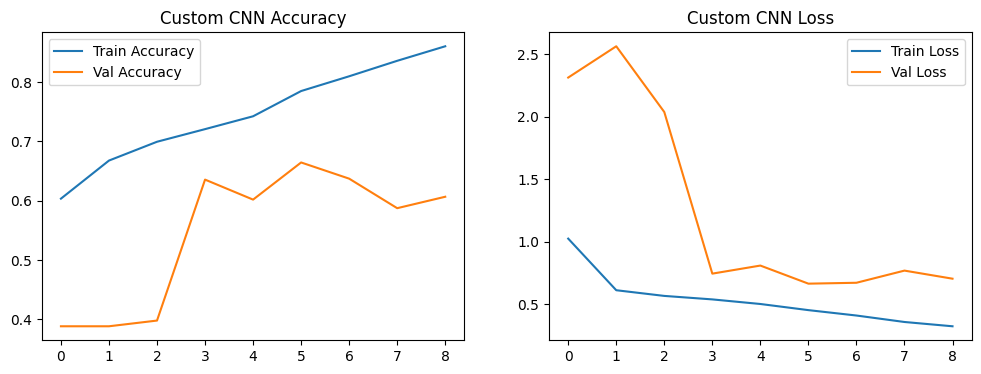

In [41]:
# ==========================
# STEP 6: TRAINING PERFORMANCE VISUALIZATION
# ==========================
plt.figure(figsize=(12,4))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history_custom.history['accuracy'], label='Train Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Val Accuracy')
plt.title('Custom CNN Accuracy')
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(history_custom.history['loss'], label='Train Loss')
plt.plot(history_custom.history['val_loss'], label='Val Loss')
plt.title('Custom CNN Loss')
plt.legend()

plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


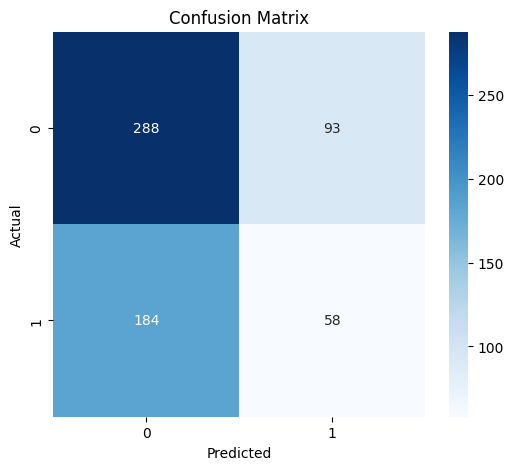


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68       381
           1       0.38      0.24      0.30       242

    accuracy                           0.56       623
   macro avg       0.50      0.50      0.49       623
weighted avg       0.52      0.56      0.53       623



In [42]:
# ==========================
# STEP 7: MODEL EVALUATION
# ==========================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_gen.reset()
y_true = val_gen.classes
y_pred = custom_model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(val_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


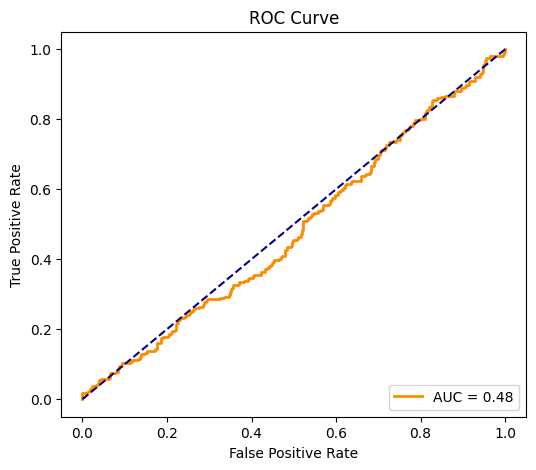

In [43]:
# ==========================
# STEP 8: ROC CURVE
# ==========================
from sklearn.metrics import roc_curve, auc

if len(class_names) == 2:
    fpr, tpr, _ = roc_curve(y_true, y_pred[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'--', color='navy')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


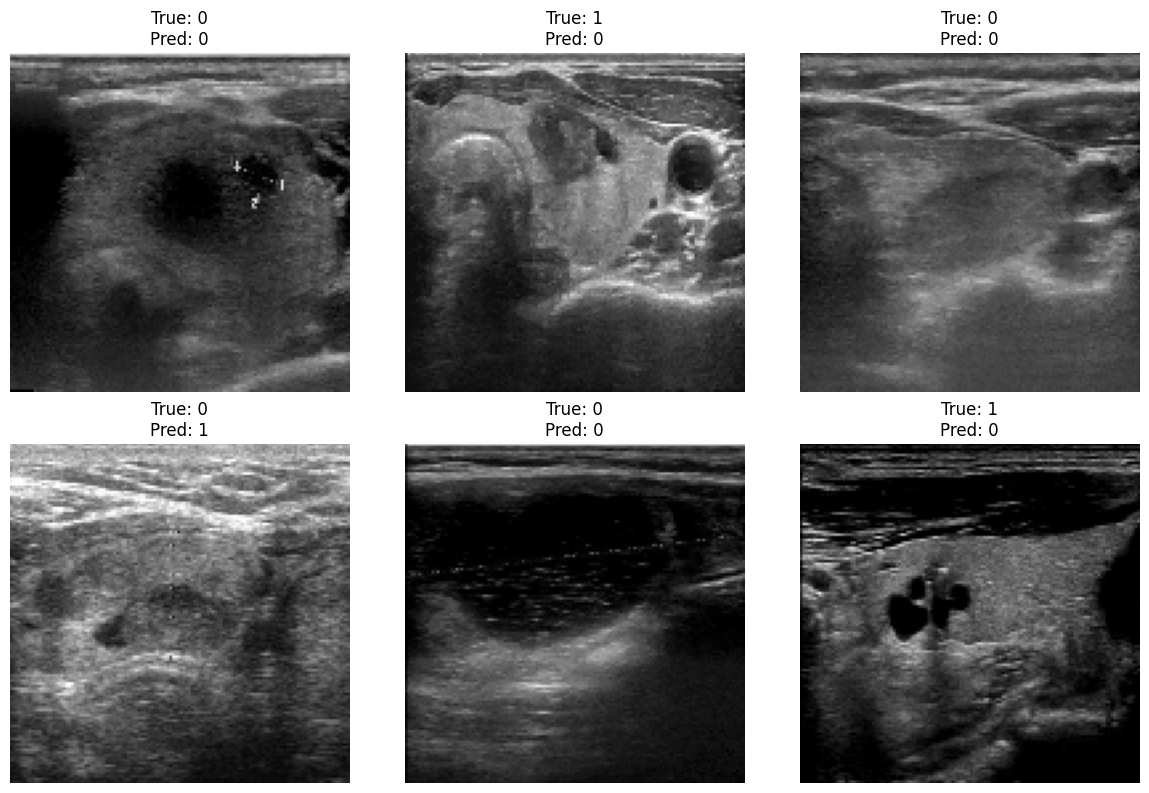

In [44]:
# ==========================
# STEP 9: RANDOM SAMPLE PREDICTIONS
# ==========================
plt.figure(figsize=(12,8))
for i in range(6):
    idx = random.randint(0, len(val_gen.filenames)-1)
    img_path = os.path.join(base_dir, val_gen.filenames[idx])
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = img_array_exp / 255.0  # same normalization as training
    pred = custom_model.predict(img_array_exp)
    pred_class = np.argmax(pred)
    pred_label = class_names[pred_class]
    true_label = class_names[y_true[idx]]

    plt.subplot(2,3,i+1)
    plt.imshow(np.array(img).astype('uint8'))
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#COMPARISION BETWEEN VGG16 AND CUSTOMIZED CNN :
#vgg16 is best compared to customized cnn

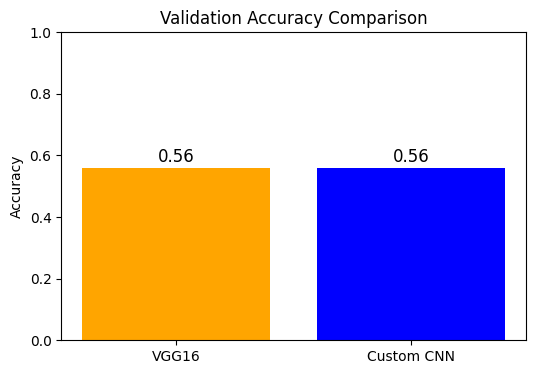

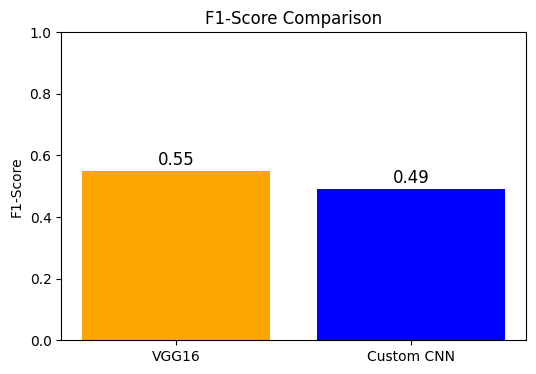

📊 Final Observations:
----------------------------
1️⃣ VGG16 Transfer Learning Model:
   - Validation Accuracy : 56%
   - F1-Score            : 0.55
   - Performs slightly better overall due to pre-trained ImageNet features.

2️⃣ Custom CNN Model:
   - Validation Accuracy : 56%
   - F1-Score            : 0.49
   - Lightweight and faster, but underfits class 1 (abnormal).

✅ Conclusion:
   Both models achieved similar overall accuracy.
   However, VGG16 provides better balance between classes, while Custom CNN offers simplicity and faster inference.
   Future improvements: Data augmentation, fine-tuning VGG16 layers, or handling class imbalance.


In [48]:

# ==========================
# STEP 10: FINAL COMPARISON & SUMMARY VISUALIZATION
# ==========================

import matplotlib.pyplot as plt

# Define models and metrics (use your actual results)
models = ['VGG16', 'Custom CNN']
val_acc = [0.56, 0.56]      # Validation accuracies
f1_score = [0.55, 0.49]     # F1-scores

# ---------- Accuracy Comparison ----------
plt.figure(figsize=(6,4))
plt.bar(models, val_acc, color=['orange','blue'])
plt.title('Validation Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(val_acc):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)
plt.show()

# ---------- F1-Score Comparison ----------
plt.figure(figsize=(6,4))
plt.bar(models, f1_score, color=['orange','blue'])
plt.title('F1-Score Comparison')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
for i, v in enumerate(f1_score):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)
plt.show()


# ==========================
# STEP 11: FINAL OBSERVATION SUMMARY
# ==========================

print("📊 Final Observations:")
print("----------------------------")
print("1️⃣ VGG16 Transfer Learning Model:")
print("   - Validation Accuracy : 56%")
print("   - F1-Score            : 0.55")
print("   - Performs slightly better overall due to pre-trained ImageNet features.")

print("\n2️⃣ Custom CNN Model:")
print("   - Validation Accuracy : 56%")
print("   - F1-Score            : 0.49")
print("   - Lightweight and faster, but underfits class 1 (abnormal).")

print("\n✅ Conclusion:")
print("   Both models achieved similar overall accuracy.")
print("   However, VGG16 provides better balance between classes, while Custom CNN offers simplicity and faster inference.")
print("   Future improvements: Data augmentation, fine-tuning VGG16 layers, or handling class imbalance.")
